# Import libraries

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.datasets import fetch_olivetti_faces
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score

# Load and standardize the data

In [ ]:
data = fetch_olivetti_faces()
X = data.data
y = data.target

print("Dataset shape:", X.shape)

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

Dataset shape: (400, 4096)


# Splitting the data

In [ ]:
X_train, X_test, y_train, y_test = train_test_split(
    X_scaled, y, test_size=0.2, random_state=42
)

# Model without PCA

In [ ]:
model = LogisticRegression(max_iter=5000)
model.fit(X_train, y_train)

y_pred = model.predict(X_test)
accuracy_before = accuracy_score(y_test, y_pred)

print("Accuracy before PCA:", accuracy_before)

Accuracy before PCA: 0.975


# Apply PCA

In [ ]:
components = [5, 10, 20, 50, 100, 200]
accuracies = []

for component in components:
    try:
        pca = PCA(n_components=component)
        X_pca = pca.fit_transform(X_scaled)

        X_train_pca, X_test_pca, y_train, y_test = train_test_split(
            X_pca, y, test_size=0.2, random_state=42
        )

        model = LogisticRegression(max_iter=5000)
        model.fit(X_train_pca, y_train)

        y_pred = model.predict(X_test_pca)
        acc = accuracy_score(y_test, y_pred)

        accuracies.append(acc)

    except Exception as e:
        print(f"Error at {component} components:", e)

component_accuracy_dict = {}
for component, accuracy in zip(components, accuracies):
  component_accuracy_dict[component] = accuracy

print(component_accuracy_dict)

{5: 0.625, 10: 0.8375, 20: 0.975, 50: 0.9625, 100: 0.975, 200: 0.975}


# Visualization



























































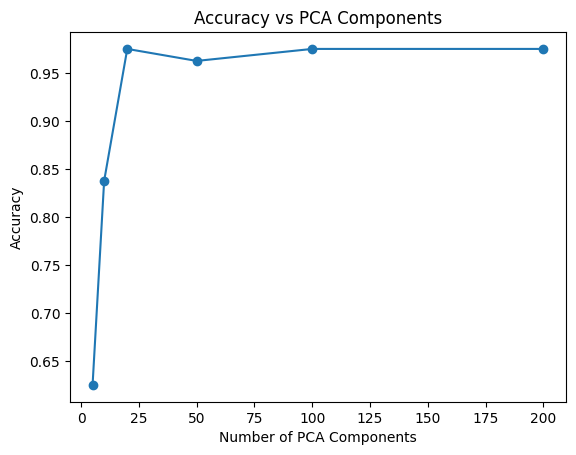

In [ ]:
plt.figure()
plt.plot(components, accuracies, marker='o')
plt.xlabel("Number of PCA Components")
plt.ylabel("Accuracy")
plt.title("Accuracy vs PCA Components")
plt.show()